In [1]:
import netket as nk
import numpy as np
import matplotlib.pyplot as plt
import json
from pyscf import gto, scf, fci
import netket.experimental as nkx

# 设置H2分子的几何构型
bond_length = 1.0  # H2平衡键长（埃）
geometry = [
    ('H', (0., 0., 0.)),
    ('H', (bond_length, 0., 0.)),
]

# 创建分子对象，使用STO-3G基组
mol = gto.M(atom=geometry, basis='STO-3G')

# 进行Hartree-Fock计算
mf = scf.RHF(mol).run(verbose=0)
E_hf = mf.e_tot
print(f"Hartree-Fock能量: {E_hf:.8f} Ha")

# 进行FCI计算作为参考
cisolver = fci.FCI(mf)
E_fci, fcivec = cisolver.kernel()
print(f"FCI能量: {E_fci:.8f} Ha")

# 使用NetKet创建哈密顿量
ha = nkx.operator.from_pyscf_molecule(mol)

/opt/miniconda3/envs/Neural/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Hartree-Fock能量: -1.06610865 Ha
FCI能量: -1.10115033 Ha


SpinOrbitalFermions 是 NetKet（特别是 netket ≥ v3.10 之后，或通过 netket.experimental）中用于描述具有自旋的费米子系统的希尔伯特空间（Hilbert space）类。它专为处理电子结构问题（如分子、固体中的多电子系统）而设计，天然支持泡利不相容原理和固定粒子数约束。

SpinOrbitalFermions 定义了一个由自旋轨道占据数构成的离散希尔伯特空间，每个自旋轨道只能被占据（1）或空（0），且满足：

费米子统计（自动通过占据数表示处理）
可选：固定总电子数、固定自旋向上/向下电子数


In [13]:
hi = nk.hilbert.SpinOrbitalFermions(
    n_orbitals=2,  # 总空间轨道数
    s = 1/2,
    n_fermions_per_spin=(1, 1)  # 每种自旋的电子数
)

# 创建采样器 - 使用费米子跳跃采样器
# 对于分子系统，我们使用完整的轨道图（完全连接）
cluster = [(0,1),(2,3)]
g = nk.graph.Graph(edges=[(0,1),(2,3)])

# 所有自旋轨道之间都允许 hopping（在满足粒子数守恒下）
g = nk.graph.Hypercube(length=4, n_dim=1)  # 或直接全连接
# 或更明确地：
edges = [(i, j) for i in range(4) for j in range(4) if i != j]
g = nk.graph.Graph(edges=edges)

sa = nk.sampler.MetropolisFermionHop(
    hi, graph=g, n_chains=16, spin_symmetric=True, sweep_size=64
)

In [3]:
hi.all_states()

Array([[0, 1, 0, 1],
       [0, 1, 1, 0],
       [1, 0, 0, 1],
       [1, 0, 1, 0]], dtype=int8)

In [14]:
import jax
import jax.numpy as jnp
from flax import nnx

class Jastrow(nnx.Module):
    def __init__(self, N: int, *, rngs: nnx.Rngs):
        k1, k2 = jax.random.split(rngs.params())
        self.J = nnx.Param(0.01 * jax.random.normal(k1, (N, N), dtype=jnp.complex128))

        self.v_bias = nnx.Param(
            0.01 * jax.random.normal(k2, (N, 1), dtype=jnp.complex128)
        )

    def __call__(self, x):
        x = x.astype(jnp.complex128)  # keep the dtypes aligned
        quad = jnp.einsum("...i,ij,...j->...", x, self.J, x)
        lin = jnp.squeeze(x @ self.v_bias, -1)  # (...,N) @ (N,1) → (...,1)
        return quad + lin


N = 4
model = Jastrow(N=N, rngs=nnx.Rngs(1))

vstate = nk.vqs.MCState(sa, model, n_samples=1008)

In [15]:
# 设置优化器
opt = nk.optimizer.Sgd(learning_rate=0.05)
sr = nk.optimizer.SR(diag_shift=0.01)

# 创建VMC驱动器
gs = nk.driver.VMC(ha, opt, variational_state=vstate, preconditioner=sr)

# 运行优化
exp_name = "h2_molecule_jastrow"

In [16]:
gs.run(300, out=exp_name)

  0%|          | 0/300 [00:00<?, ?it/s]

/opt/miniconda3/envs/Neural/lib/python3.11/site-packages/netket/optimizer/qgt/qgt_onthefly.py:139: HolomorphicUndeclaredWarning: 
Defaulting to `holomorphic=False`, but this might lead to increased
computational cost or disabled features. Check if your variational
function is holomorphic, and if so specify `holomorphic=True`as an extra
keyword argument.

To silence this warning, specify the `holomorphic=False/True` keyword
argument.

To numerically check whether your variational function is or not holomorphic
you can use the following snippet:

```python
   vs = nk.vqs.MCState(...)

   nk.utils.is_probably_holomorphic(vs._apply_fun, vs.parameters, vs.samples, vs.model_state)
```

if `nk.utils.is_probably_holomorphic` returns False, then your function is not holomorphic.
If it returns True, it is probably holomorphic.


-------------------------------------------------------
For more detailed informations, visit the following link:
	 https://netket.readthedocs.io/en/latest/api/_generate

(JsonLog('h2_molecule_jastrow', mode=write, autoflush_cost=0.005)
   Runtime cost:
   	Log:    0.06897759437561035
   	Params: 0.06525468826293945,)

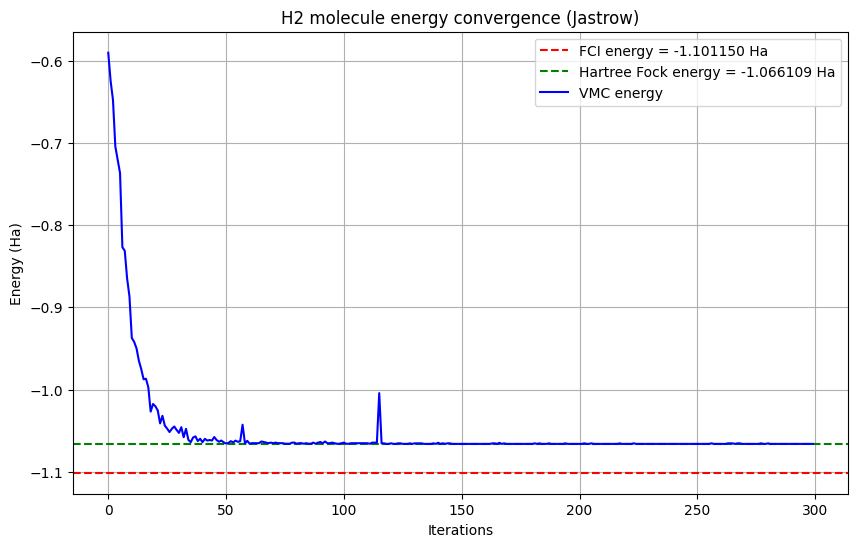


最终VMC能量: -1.06609432 Ha
与FCI能量误差: 0.03505601 Ha


In [20]:
############## 绘图 #################
# 获取精确对角化能量（FCI能量）
ed_energies = np.array([E_fci])  # H2只有一个基态能量

# 读取日志数据
with open(f"{exp_name}.log") as f:
    data = json.load(f)

x = data["Energy"]["iters"]
y = data["Energy"]["Mean"]['real']

# 绘制能量收敛曲线
plt.figure(figsize=(10, 6))
plt.axhline(ed_energies[0], color="red", linestyle="--", label=f"FCI energy = {E_fci:.6f} Ha")
plt.axhline(E_hf, color="green", linestyle="--", label=f"Hartree Fock energy = {E_hf:.6f} Ha")
plt.plot(x, y, 'b-', label="VMC energy")
plt.xlabel("Iterations")
plt.ylabel("Energy (Ha)")
plt.title("H2 molecule energy convergence (Jastrow)")
plt.legend()
plt.grid(True)
plt.show()

# 打印最终结果
print(f"\n最终VMC能量: {y[-1]:.8f} Ha")
print(f"与FCI能量误差: {abs(y[-1] - E_fci):.8f} Ha")

In [28]:
# 假设 vstate 是你已经训练好的 MCState
import numpy as np
import matplotlib.pyplot as plt

# 1. 生成大量样本以获得准确的概率分布
n_samples = 10000  # 增加样本数量以获得更准确的概率
samples = vstate.sample(n_samples=n_samples)

# 2. 将样本重塑为二维数组 (n_samples, n_orbitals)
samples_flat = samples.reshape(-1, samples.shape[-1])

# 3. 统计每个组态的出现次数
unique_configs, counts = np.unique(samples_flat, axis=0, return_counts=True)

# 4. 计算概率
probabilities = counts / np.sum(counts)

# 5. 按概率排序
sorted_indices = np.argsort(probabilities)[::-1]
sorted_configs = unique_configs[sorted_indices]
sorted_probs = probabilities[sorted_indices]

print("组态及其概率分布:")
print("组态(轨道占据)    概率      物理解释")
print("-" * 50)
for i, (config, prob) in enumerate(zip(sorted_configs[:10], sorted_probs[:10])):  # 显示前10个主要组态
    # 解释组态的物理意义
    occupied_orbitals = np.where(config == 1)[0]
    print(f"{config}         {prob:.6f}   电子占据轨道: {occupied_orbitals}")

组态及其概率分布:
组态(轨道占据)    概率      物理解释
--------------------------------------------------
[0 0 1 1]         0.364200   电子占据轨道: [2 3]
[1 1 0 0]         0.360500   电子占据轨道: [0 1]
[1 0 1 0]         0.275300   电子占据轨道: [0 2]
